## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)


# Cloudless Mosaic and OpenEO

This notebook demonstrates how to build a cloudless mosaic from Sentinel-2 L2A data over a chosen time window (e.g. 6 months or 1 year). The underlying logic follows the [Sentinel Hub cloudless mosaic evalscript](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/): it uses the **Scene Classification Layer (SCL)** to keep only valid, non-cloudy pixels, then for each output pixel takes the first quartile of valid reflectance values per band (B04, B03, B02 for R, G, B). If no valid pixels exist, it falls back to the first quartile of “invalid” (e.g. cloudy) values; if there are no values at all, the pixel is set to zero. Because the script aggregates many acquisitions (the original evalscript uses one year of data), processing can be compute- and time-intensive. It is recommended to use a small area (e.g. 256×256 px). It is recommended to balance the length of the acquisition period, the completeness of the result, and the spatial extent. When using SCL, nearest-neighbour resampling at about 20 m/px or coarser is important so that the classification labels are not blurred. An example of the kind of result is New Zealand’s 10 m cloudless mosaic, available at: [NZ 10m Satellite Imagery 2017](https://data.linz.govt.nz/layer/93652-nz-10m-satellite-imagery-2017/).

## Overview

In this notebook we will:
1. Connect to an OpenEO backend
2. Define an area of interest (e.g. a small region)
3. Load Sentinel-2 L2A data (with SCL) over a chosen period
4. Apply the cloudless-mosaic logic (SCL-based validation, first-quartile per band)
5. Export and visualise the cloud-free RGB mosaic

## How the cloudless mosaic works in the Evalscript

- **Input**: Sentinel-2 L2A with bands **B04** (red), **B03** (green), **B02** (blue) and **SCL** (scene classification) over three months.
- **Validation**: Only pixels with positive values and are passing the SCL/cloud check are “valid”. Excluded are: cloud shadow (3), high/medium cloud probability (9, 8), thin cirrus (10), snow/ice (11), saturated/defective (1). Optionally, low cloud probability (7) and dark feature shadow (2) can be excluded. This process creates valid and invalid arrays with values over a time period of three months. This means each valid and invalid array has x, y, band, and time dimensions.
- **Time dimension reduction**: For each pixel, valid reflectance values over the time window are collected per band, sorted, and the **first quartile** is taken (separately for R, G, B). 
- **Mosaicking**: If there are no valid values, the first quartile of invalid values is used; if there are none, the pixel is set to 0.
- **Output**: A single RGB composite representing a cloud-free view of the area over the selected period.

## Modifications to be made for translating the Evalscript to OpenEO UDP

- All other steps remain the same as in the Evalscript reference, except the time dimension reduction
- **Time dimension reduction**: Instead of taking the first quartile of each band, we're taking the median values over the three months period for each band. 


In [ ]:
import openeo
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from PIL import Image
from openeo.processes import neq, and_, array_create, not_, if_, gt, absolute

## Connect to OpenEO-Titiler Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [10]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


# Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates for an area in Central Portugal

In [11]:
# spatial_extent = {"west" : 12.3793, "south" : 45.8996, "east" : 12.7918, "north" : 46.1364}
spatial_extent = {"west" : 8.53, "south" : 42.10, "east" : 8.72, "north" : 42.19}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data. We need multiple bands:

- **B04** (Red, 664.6 nm): Red band
- **B03** (Green, 559.8 nm): Green band
- **B02** (Blue, 492.4 nm): Blue band
- **SCL**: Scene classification data with the following classification:
    - 0 - No data
    - 1 - Saturated / Defective
    - 2 - Dark Area Pixels
    - 3 - Cloud Shadows
    - 4 - Vegetation
    - 5 - Bare Soils
    - 6 - Water
    - 7 - Clouds low probability / Unclassified
    - 8 - Clouds medium probability
    - 9 - Clouds high probability
    - 10 - Cirrus
    - 11 - Snow / Ice

In [12]:
end_date = "2025-11-30"  
end_dt = datetime.strptime(end_date, "%Y-%m-%d")
start_dt = end_dt - timedelta(days=1 * 7) 
start_date = start_dt.strftime("%Y-%m-%d")

print(f"Loading data from {start_date} to {end_date}")

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[start_date, end_date],
    bands=[
        "B02",
        "B03",
        "B04",
        "SCL"
    ],
)

Loading data from 2025-11-23 to 2025-11-30


In [13]:
# Exclude 0, 1, 3, 8, 9, 10, 11
def validate(scl_band):
    return and_(
        neq(scl_band, 3),
        and_(
            neq(scl_band, 9),
            and_(
                neq(scl_band, 8),
                and_(
                    neq(scl_band, 10),
                    and_(
                        neq(scl_band, 11),
                        and_(
                            neq(scl_band, 1),
                            neq(scl_band, 0)
                        )
                    )
                )
            )
        )
    )

In [ ]:
# Step 1: Get valid array
def get_bands(data):
    B02, B03, B04, SCL = (
        data[0], 
        data[1], 
        data[2], 
        data[3]
    )
    
    B02 = B02 / 10000
    B03 = B03 / 10000
    B04 = B04 / 10000

    return B02, B03, B04, SCL

def valid_arrays(data):
    B02, B03, B04, SCL = get_bands(data)

    positive = and_(gt(B02, 0), and_(gt(B03, 0), gt(B04, 0)))
    mask = validate(SCL)
    valid_arr = and_(positive, mask)

    return array_create([
        if_(valid_arr, B04, None),
        if_(valid_arr, B03, None),
        if_(valid_arr, B02, None)
    ])

# Had to apply negative signs to band values, as we're using the maximum values over the merging cube as the overlap_resolver
# This means that the merging will prioritize values from valid_arrays during the merging
# Treating invalid_arrays as the fallback only
def invalid_arrays(data):
    B02, B03, B04, SCL = get_bands(data)
    
    positive = and_(gt(B02, 0), and_(gt(B03, 0), gt(B04, 0)))
    mask = validate(SCL)
    invalid_arr = and_(positive, not_(mask))

    return array_create([
        if_(invalid_arr, (B04 * -1), None),
        if_(invalid_arr, (B03 * -1), None),
        if_(invalid_arr, (B02 * -1), None)
    ])

In [ ]:
# Create valid and invalid cubes separately
create_valid = s2cube.apply_dimension(dimension="bands", process=valid_arrays)
create_invalid = s2cube.apply_dimension(dimension="bands", process=invalid_arrays)

# Reduce time dims with median
reduce_valid = create_valid.reduce_dimension(dimension="t", reducer="median")
reduce_invalid = create_invalid.reduce_dimension(dimension="t", reducer="median")

# Mosaicking, prioritizing values from the valid array
mosaic = reduce_invalid.merge_cubes(reduce_valid, overlap_resolver="max")

# To return the negative into positive
mosaic = mosaic.apply(process=absolute)

mosaic_image = mosaic.linear_scale_range(input_min=0, input_max=1, output_min=0, output_max=255)

mosaic_image = mosaic_image.save_result("PNG")

In [ ]:
mosaic_image.download("mosaic_cloudless.png")

## Visualize the Result

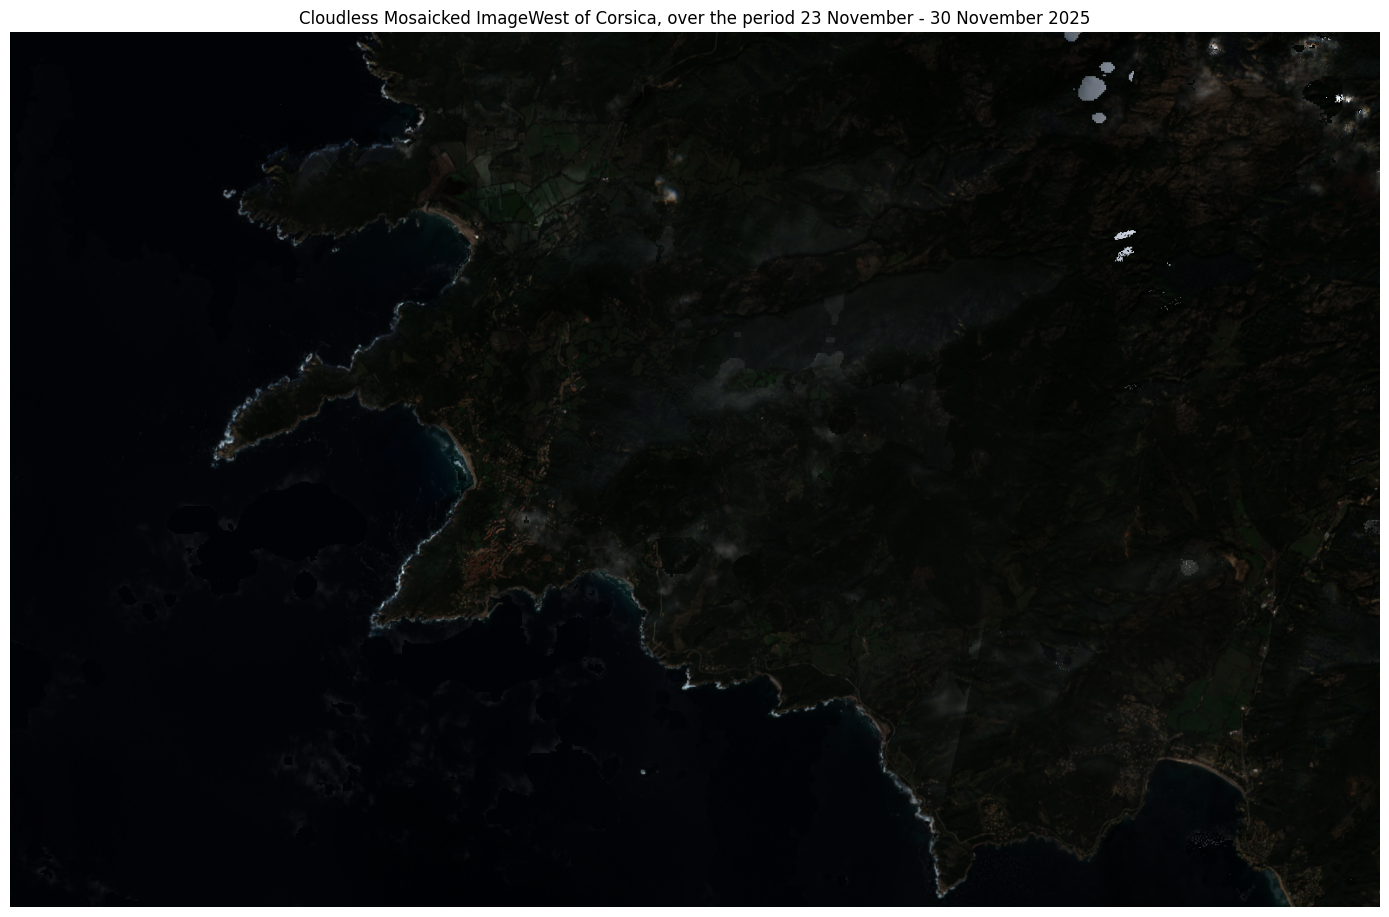

In [5]:
# Load and display the image
img = Image.open("mosaic_cloudless.png")

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
ax.imshow(img)
ax.set_title(
    "Cloudless Mosaicked Image"
    "West of Corsica, over the period 23 November - 30 November 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Limitations
- **Different temporal reducer than the original Evalscript**: 
    - The original Sentinel Hub cloudless mosaic takes the first quartile (25th percentile) of valid reflectance values per band over time (with a fallback to the first quartile of invalid values), whereas this OpenEO implementation uses the median over time because a quartile reducer is not available. As a result, the OpenEO mosaic is not an exact reproduction of the reference Evalscript.
- **No explicit brightening / tone-mapping step**: 
    - In this notebook we output reflectances more directly without a dedicated brightening or gamma/tone-mapping step, which can also contribute to a darker-looking image.
- **Compute- and time-intensive for large areas or long periods**: 
    - As in the original approach, the method aggregates many Sentinel‑2 acquisitions and computes per-pixel statistics over time. This becomes computationally expensive for long time windows or large areas of interest, so in practice it is advisable to work with relatively small regions (e.g. ~256×256 px tiles) and moderate acquisition periods (e.g. one month). 

    - In this notebook we use a much shorter, seven‑day acquisition period for demonstration purposes, which reduces the computational load but also limits the number of available observations per pixel and can therefore make limited samples to create the mosaic.

    - The limited samples also reduce the chances of acquiring cloud-free observations which could lead to a dark image, aside from applying brightening step. 

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script:** [Cloudless Mosaic](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/)

**Author:** -

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.